In [4]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

file_you   = 'hello1.wav'
file_friend= 'hello2.wav'
sr_desired = 22050

def load_and_preprocess(path, sr=sr_desired, trim=True):
    x, sr = librosa.load(path, sr=sr, mono=True)
    if trim:
        x, _ = librosa.effects.trim(x, top_db=30)
    rms = np.sqrt(np.mean(x**2)) + 1e-9
    x = x / rms
    return x, sr

x1, sr = load_and_preprocess(file_you)
x2, sr = load_and_preprocess(file_friend)



In [5]:
hop = 256
frame_len = 1024

def short_time_energy_frames(x, frame_len=frame_len, hop=hop):
    frames = librosa.util.frame(x, frame_length=frame_len, hop_length=hop)
    energy = np.sum(frames**2, axis=0)
    return energy[np.newaxis, :]

E1 = short_time_energy_frames(x1)
E2 = short_time_energy_frames(x2)

D_wave, wp_wave = librosa.sequence.dtw(X=E1, Y=E2, metric='euclidean')

dist_wave = D_wave[-1, -1] / len(wp_wave)
print(f'Waveform-frame DTW total cost: {D_wave[-1,-1]:.3f}, avg per-step: {dist_wave:.3f}')

n_mfcc = 13
hop_length_mfcc = 512
mfcc1 = librosa.feature.mfcc(y=x1, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length_mfcc)
mfcc2 = librosa.feature.mfcc(y=x2, sr=sr, n_mfcc=n_mfcc, hop_length=hop_length_mfcc)

# cepstral mean normalisation (per coefficient)
mfcc1 = mfcc1 - np.mean(mfcc1, axis=1, keepdims=True)
mfcc2 = mfcc2 - np.mean(mfcc2, axis=1, keepdims=True)

D_mfcc, wp_mfcc = librosa.sequence.dtw(X=mfcc1, Y=mfcc2, metric='euclidean')

total_cost_mfcc = D_mfcc[-1, -1]
avg_cost_mfcc = total_cost_mfcc / len(wp_mfcc)
print(f'MFCC DTW total cost: {total_cost_mfcc:.3f}, avg per-step: {avg_cost_mfcc:.3f}')



Waveform-frame DTW total cost: 13344.565, avg per-step: 114.056
MFCC DTW total cost: 3157.509, avg per-step: 70.167


In [6]:
t1 = np.arange(len(x1)) / sr
t2 = np.arange(len(x2)) / sr

time_frames_a = librosa.frames_to_time(np.arange(mfcc1.shape[1]), sr=sr, hop_length=hop_length_mfcc)
time_frames_b = librosa.frames_to_time(np.arange(mfcc2.shape[1]), sr=sr, hop_length=hop_length_mfcc)

ts_a = mfcc1[0, :]  # first MFCC coeff as a compact feature to plot (shape: frames_a,)
ts_b = mfcc2[0, :]  # shape: frames_b,

best_path = np.array(wp_mfcc)  # shape (N_steps, 2) with columns [idx_X, idx_Y]
best_path = best_path[::-1]


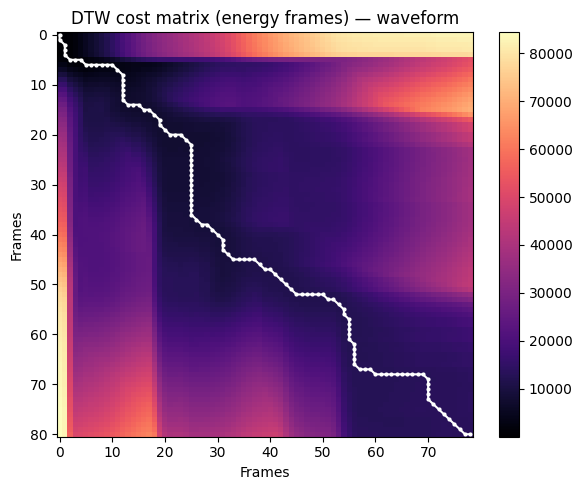

In [7]:
plt.figure(figsize=(6,5))
librosa.display.specshow(D_wave, x_axis='frames', y_axis='frames')
plt.title('DTW cost matrix (energy frames) — waveform')
wp_y, wp_x = zip(*wp_wave)
plt.plot(wp_x, wp_y, marker='o', markersize=2, color='w')
plt.gca().invert_yaxis()
plt.colorbar()
plt.tight_layout()
plt.show()


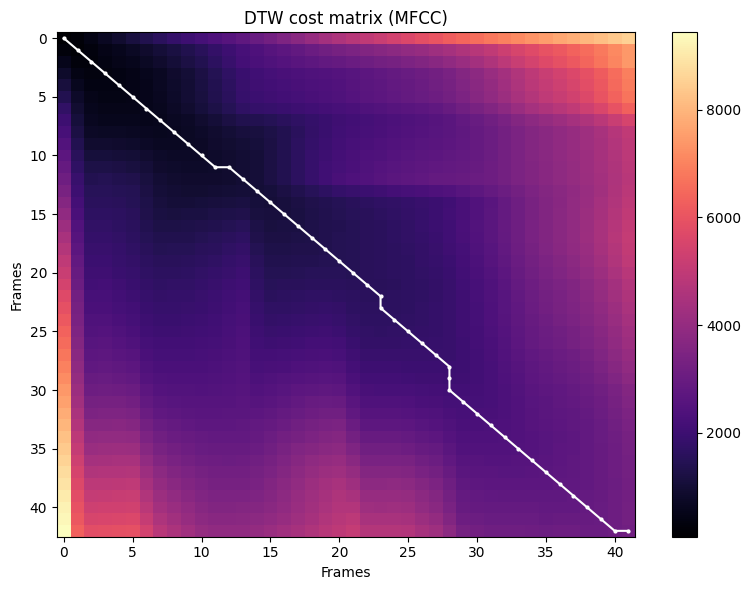

In [8]:
plt.figure(figsize=(8,6))
librosa.display.specshow(D_mfcc, x_axis='frames', y_axis='frames')
plt.title('DTW cost matrix (MFCC)')
wp_y_m, wp_x_m = zip(*wp_mfcc)
plt.plot(wp_x_m, wp_y_m, marker='o', markersize=2, color='w')
plt.gca().invert_yaxis()
plt.colorbar()
plt.tight_layout()
plt.show()


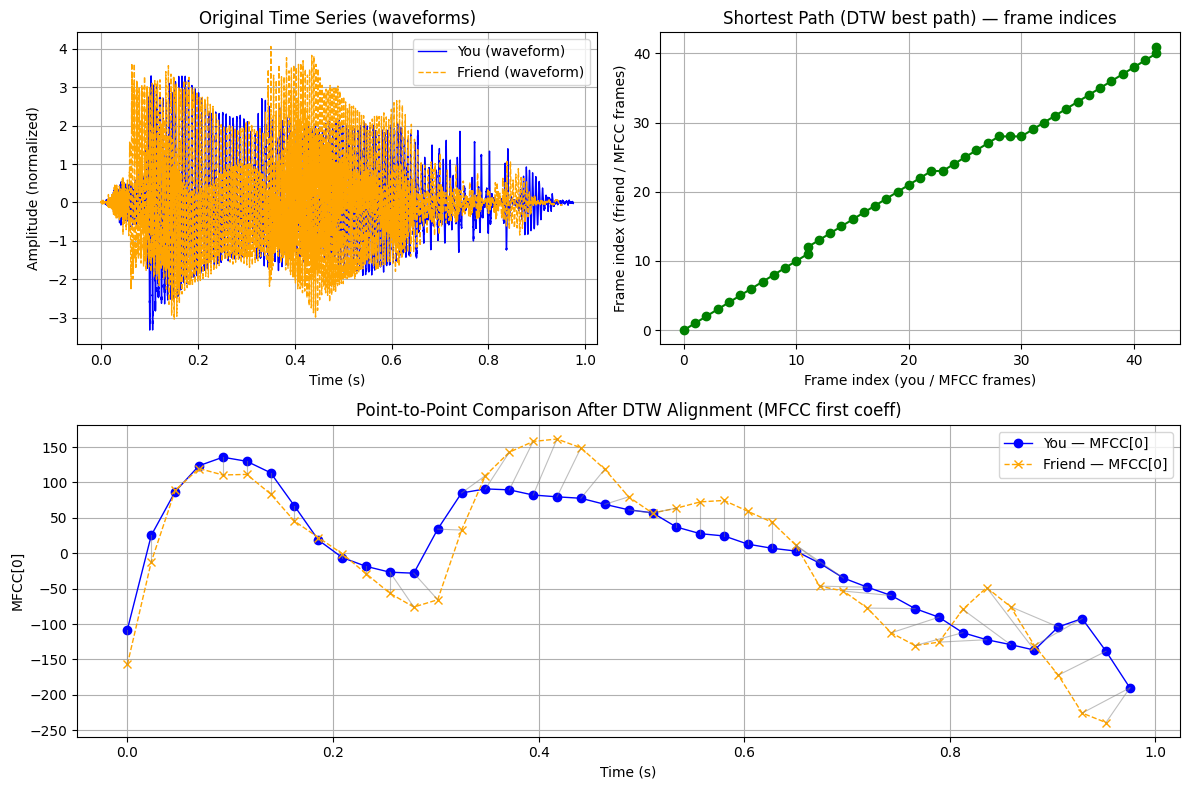

In [9]:

fig = plt.figure(figsize=(12, 8))

ax1 = plt.subplot2grid((2, 2), (0, 0))
ax1.plot(t1, x1, label='You (waveform)', color='blue', linewidth=1)
ax1.plot(t2, x2, label='Friend (waveform)', linestyle='--', color='orange', linewidth=1)
ax1.set_title('Original Time Series (waveforms)')
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Amplitude (normalized)')
ax1.legend()
ax1.grid(True)

ax2 = plt.subplot2grid((2, 2), (0, 1))
ax2.plot(best_path[:, 0], best_path[:, 1], color='green', marker='o', linestyle='-')
ax2.set_title('Shortest Path (DTW best path) — frame indices')
ax2.set_xlabel('Frame index (you / MFCC frames)')
ax2.set_ylabel('Frame index (friend / MFCC frames)')
ax2.grid(True)

ax3 = plt.subplot2grid((2, 2), (1, 0), colspan=2)
ax3.plot(time_frames_a, ts_a, label='You — MFCC[0]', color='blue', marker='o', linewidth=1)
ax3.plot(time_frames_b, ts_b, label='Friend — MFCC[0]', color='orange', marker='x', linestyle='--', linewidth=1)

for (ia, ib) in best_path:
    if ia < len(time_frames_a) and ib < len(time_frames_b):
        ta = time_frames_a[ia]
        tb = time_frames_b[ib]
        va = ts_a[ia]
        vb = ts_b[ib]
        ax3.plot([ta, tb], [va, vb], color='grey', linestyle='-', linewidth=0.8, alpha=0.5)

ax3.set_title('Point-to-Point Comparison After DTW Alignment (MFCC first coeff)')
ax3.set_xlabel('Time (s)')
ax3.set_ylabel('MFCC[0]')
ax3.legend()
ax3.grid(True)

plt.tight_layout()
plt.show()


In [10]:

print("\nSample of first 12 mapping pairs (frame_in_you -> frame_in_friend):")
for i, (iy, ix) in enumerate(best_path[:12]):
    print(f"{iy} -> {ix}")




Sample of first 12 mapping pairs (frame_in_you -> frame_in_friend):
0 -> 0
1 -> 1
2 -> 2
3 -> 3
4 -> 4
5 -> 5
6 -> 6
7 -> 7
8 -> 8
9 -> 9
10 -> 10
11 -> 11
